# Physics-Informed Neural Networks for Activity Coefficient Prediction

This notebook presents the development of a physics-informed neural network (PINN) to predict activity coefficients using processed experimental data. By embedding thermodynamic constraints directly into the loss function, we incorporate domain knowledge into the model, ensuring thermodynamic consistency while leveraging a data-driven approach.

## Dependencies

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from pathlib import Path
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from torchmetrics.regression import R2Score

## PINN modeling

### Designing the Neural Network Components

Fix the random seed to be used

In [2]:
torch.manual_seed(42)

Define the architecture of the neural network

In [3]:
class NeuralNetArchitecture(nn.Module):
    def __init__(self, in_dim: int, out_dim: int) -> None:
        super().__init__()
        self.layer_1 = nn.Linear(in_dim, 64)
        self.layer_2 = nn.Linear(64, 32)
        self.layer_3 = nn.Linear(32, 16)
        self.layer_4 = nn.Linear(16, out_dim)

    def forward(self, x):
        x = F.relu(self.layer_1(x))
        x = F.relu(self.layer_2(x))
        x = F.relu(self.layer_3(x))
        x = self.layer_4(x)

        return x

Implement a custom loss function that enforces thermodynamic consistency by embedding the Gibbs-Duhem equation into the standard MSE loss

In [4]:
def gibbs_duhem_loss(
    y_pred: torch.Tensor,
    y_true: torch.Tensor,
    X: torch.Tensor,
    model: torch.nn.Module,
    lambda_gd: float = 1.0,
    lambda_l1: float = 0.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    # MSE loss
    mse_loss = F.mse_loss(y_pred, y_true, reduction="mean")

    # Calculate ln(gamma)
    ln_gamma1 = y_pred[:, 0]
    ln_gamma2 = y_pred[:, 1]

    # Compute partial derivatives
    dgamma1_dx1 = torch.autograd.grad(
        ln_gamma1,
        X,
        grad_outputs=torch.ones_like(ln_gamma1),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    dgamma2_dx1 = torch.autograd.grad(
        ln_gamma2,
        X,
        grad_outputs=torch.ones_like(ln_gamma2),
        create_graph=True,
        allow_unused=True,
    )[0][:, 2]

    # Compute Gibbs-Duhem term
    x1 = X[:, 2]
    x2 = X[:, 5]
    gibbs_duhem_term = x1 * dgamma1_dx1 + x2 * dgamma2_dx1

    # Physics-based loss
    gd_loss = torch.mean(gibbs_duhem_term**2) * lambda_gd

    # L1 regularization term
    l1_loss = (sum(p.abs().sum() for p in model.parameters())) * lambda_l1

    # Total loss
    loss = mse_loss + gd_loss + l1_loss

    return loss, mse_loss, gd_loss, gibbs_duhem_term

### Reading the data

Defining the data path conveniently:

In [5]:
DATA_PATH = Path("../data")

Reading the data into a `pandas.DataFrame`:

In [6]:
data = pd.read_csv(DATA_PATH / "processed" / "toy_problem_training_dataset.csv")

data

,r_1,q_1,x_1,r_2,q_2,x_2,T,ln_gamma_1,ln_gamma_2
0,9.9262,8.296,0.00,5.8486,4.936,1.00,398.8390,0.102990,0.000000
1,9.9262,8.296,0.01,5.8486,4.936,0.99,399.2130,0.098514,0.000020
2,9.9262,8.296,0.02,5.8486,4.936,0.98,399.5900,0.094219,0.000080
3,9.9262,8.296,0.03,5.8486,4.936,0.97,399.9710,0.090097,0.000180
4,9.9262,8.296,0.04,5.8486,4.936,0.96,400.3550,0.086132,0.000320
...,...,...,...,...,...,...,...,...,...
11671,13.2982,10.996,0.95,3.9243,3.668,0.05,356.0979,0.001092,0.733569
11672,13.2982,10.996,0.96,3.9243,3.668,0.04,361.4270,0.000662,0.719713
11673,13.2982,10.996,0.97,3.9243,3.668,0.03,368.6836,0.000347,0.697929
11674,13.2982,10.996,0.98,3.9243,3.668,0.02,379.5885,0.000139,0.662112


### PINN training

Defining model constants

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 10000
LAMBDA_GD = 1

Split the data into train and test

In [8]:
features = data.iloc[:, :-2].values
labels = data.iloc[:, -2:].values

# Separate the test data
X, X_test, y, y_test = train_test_split(
    features, labels, test_size=0.1, random_state=42
)

Defining the Optuna objective function to find the best hyperparameters

In [9]:
def objective(trial):
    # Hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    lambda_gd = LAMBDA_GD
    lambda_l1 = trial.suggest_float("lambda_l1", 1e-5, 1e-2, log=True)

    # Define the cross-validation folds
    k_folds = 5
    cv = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    val_losses = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Scale the data
        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        # Convert to tensors
        X_train_tensor = torch.tensor(
            X_train_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        X_val_tensor = torch.tensor(
            X_val_scaled, dtype=torch.float32, requires_grad=True
        ).to(DEVICE)
        y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
        y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

        # Model and optimizer
        input_size = X_train.shape[1]
        output_size = 2
        model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

        # Early stopping setup
        best_val_loss = float("inf")
        patience = EPOCHS / 10
        patience_counter = 0

        for epoch in range(EPOCHS):
            # Training
            model.train()
            outputs = model(X_train_tensor)
            loss = gibbs_duhem_loss(
                outputs, y_train_tensor, X_train_tensor, model, lambda_gd, lambda_l1
            )[0]

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Validation
            model.eval()
            val_outputs = model(X_val_tensor)
            val_loss = gibbs_duhem_loss(
                val_outputs, y_val_tensor, X_val_tensor, model, lambda_gd, lambda_l1
            )[0]

            if val_loss.item() < best_val_loss:
                best_val_loss = val_loss.item()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}. Best val loss: {best_val_loss:.4f}"
                )
                break

        val_losses.append(best_val_loss)

    return np.mean(val_losses)

Get the best hyperparameters

In [10]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best hyperparameters:")
print(study.best_params)

[I 2025-07-25 21:36:16,944] A new study created in memory with name: no-name-21c8a8f9-551b-4dab-b960-ec835d16ccc0
[I 2025-07-25 21:52:10,251] Trial 0 finished with value: 0.04493676871061325 and parameters: {'learning_rate': 5.940323645121679e-05, 'lambda_l1': 3.6568966907967713e-05}. Best is trial 0 with value: 0.04493676871061325.
[I 2025-07-25 22:08:10,695] Trial 1 finished with value: 0.06819599866867065 and parameters: {'learning_rate': 0.0001420249288937071, 'lambda_l1': 0.0003031513481740949}. Best is trial 0 with value: 0.04493676871061325.


Early stopping at epoch 9471. Best val loss: 0.2911
Early stopping at epoch 4536. Best val loss: 0.2655
Early stopping at epoch 5586. Best val loss: 0.2686
Early stopping at epoch 6766. Best val loss: 0.2614


[I 2025-07-25 22:19:46,339] Trial 2 finished with value: 0.26964104175567627 and parameters: {'learning_rate': 0.00018194515618411285, 'lambda_l1': 0.009087277885363305}. Best is trial 0 with value: 0.04493676871061325.
[I 2025-07-25 22:35:45,062] Trial 3 finished with value: 0.1993152141571045 and parameters: {'learning_rate': 1.5622189842177135e-05, 'lambda_l1': 0.000350233756258919}. Best is trial 0 with value: 0.04493676871061325.
[I 2025-07-25 22:51:46,303] Trial 4 finished with value: 0.17068377137184143 and parameters: {'learning_rate': 0.00010562443723862153, 'lambda_l1': 0.0014308188396976015}. Best is trial 0 with value: 0.04493676871061325.
[I 2025-07-25 23:07:17,121] Trial 5 finished with value: 0.07370873391628266 and parameters: {'learning_rate': 0.00056352676630113, 'lambda_l1': 0.0006434306703110268}. Best is trial 0 with value: 0.04493676871061325.
[I 2025-07-25 23:23:07,376] Trial 6 finished with value: 0.03204878531396389 and parameters: {'learning_rate': 0.000616966

Early stopping at epoch 2917. Best val loss: 0.3219
Early stopping at epoch 1362. Best val loss: 0.2963
Early stopping at epoch 1536. Best val loss: 0.2989
Early stopping at epoch 1524. Best val loss: 0.2919


[I 2025-07-25 23:41:34,870] Trial 8 finished with value: 0.30034359097480773 and parameters: {'learning_rate': 0.009825532019531166, 'lambda_l1': 0.008599251959053256}. Best is trial 7 with value: 0.02161816693842411.


...

Early stopping at epoch 3097. Best val loss: 0.2751


[I 2025-07-26 08:00:40,925] Trial 41 finished with value: 0.009544384479522706 and parameters: {'learning_rate': 0.0038412314199588763, 'lambda_l1': 1.0771408989706022e-05}. Best is trial 36 with value: 0.0076165364123880865.
[I 2025-07-26 08:17:03,464] Trial 42 finished with value: 0.007583532389253378 and parameters: {'learning_rate': 0.006872606689874531, 'lambda_l1': 1.017577421892574e-05}. Best is trial 42 with value: 0.007583532389253378.
[I 2025-07-26 08:33:26,843] Trial 43 finished with value: 0.009848069958388805 and parameters: {'learning_rate': 0.007335633551136285, 'lambda_l1': 1.59603757013791e-05}. Best is trial 42 with value: 0.007583532389253378.
[I 2025-07-26 08:49:51,670] Trial 44 finished with value: 0.014577106572687626 and parameters: {'learning_rate': 0.0017740209321040808, 'lambda_l1': 2.392627807788924e-05}. Best is trial 42 with value: 0.007583532389253378.
[I 2025-07-26 09:06:11,916] Trial 45 finished with value: 0.010853405855596066 and parameters: {'learning

Early stopping at epoch 9936. Best val loss: 0.0092


[I 2025-07-26 09:55:24,960] Trial 48 finished with value: 0.010362901724874973 and parameters: {'learning_rate': 0.009944179385058078, 'lambda_l1': 1.9317900687114875e-05}. Best is trial 42 with value: 0.007583532389253378.
[I 2025-07-26 10:11:40,755] Trial 49 finished with value: 0.018633223697543146 and parameters: {'learning_rate': 0.0007587011670390856, 'lambda_l1': 3.1460397204664735e-05}. Best is trial 42 with value: 0.007583532389253378.


Best hyperparameters:
{'learning_rate': 0.006872606689874531, 'lambda_l1': 1.017577421892574e-05}


The best values obtained for each optimized hyperparameter are:

- `learning_rate` → 0.00975135569119805
- `lambda_l1` → 1.0151039172898366e-05

The hyperparameter `lambda_gd` was excluded from the optimization process. In previous experiments, its inclusion led to insufficient enforcement of the physics constraints. Therefore, based on manual testing, we fixed `lambda_gd` to a value of 1 and focused the optimization on the remaining hyperparameters.

### PINN evaluation

Define the best hyperparameters

In [11]:
best_lr = study.best_params["learning_rate"]
best_lambda_gd = LAMBDA_GD
best_lambda_l1 = study.best_params["lambda_l1"]

Define tensors to be used during training

In [12]:
# Split the dataset into training and validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Scale features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to tensors and move to device
X_train_tensor = torch.tensor(
    X_train_scaled, dtype=torch.float32, requires_grad=True
).to(DEVICE)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32, requires_grad=True).to(
    DEVICE
)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(DEVICE)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(DEVICE)

Evaluating the model with the best hyperparameters

In [13]:
# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

# Early stopping setup
best_val_loss = float("inf")
best_model_state = None
patience = EPOCHS / 10
patience_counter = 0

for epoch in range(EPOCHS):
    # Training
    model.train()
    outputs = model(X_train_tensor)
    loss = gibbs_duhem_loss(
        outputs, y_train_tensor, X_train_tensor, model, best_lambda_gd, best_lambda_l1
    )[0]

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    val_outputs = model(X_val_tensor)
    val_loss = gibbs_duhem_loss(
        val_outputs,
        y_val_tensor,
        X_val_tensor,
        model,
        best_lambda_gd,
        best_lambda_l1,
    )[0]

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}: Training loss -> {loss.item():.4f}, Validation loss -> {val_loss.item():.4f}"
        )

    if patience_counter >= patience:
        print(
            f"Early stopping at epoch {epoch + 1}. Best validation loss: {best_val_loss:.4f}"
        )
        break

# Load best model parameters
if best_model_state is not None:
    model.load_state_dict(best_model_state)

# Final model evaluation
model.eval()
test_outputs = model(X_test_tensor)
test_loss, test_mse, test_gd, test_residuals = gibbs_duhem_loss(
    test_outputs, y_test_tensor, X_test_tensor, model, best_lambda_gd, best_lambda_l1
)

print(f"\nFinal Test Loss: {test_loss.item():.4f}")
print(f" - Test MSE Loss: {test_mse.item():.4f}")
print(f" - Test GD Loss: {test_gd.item():.4f}")

Epoch 20: Training loss -> 0.1639, Validation loss -> 0.1635
Epoch 40: Training loss -> 0.1313, Validation loss -> 0.1383
Epoch 60: Training loss -> 0.1133, Validation loss -> 0.1206
Epoch 80: Training loss -> 0.0982, Validation loss -> 0.1062
Epoch 100: Training loss -> 0.0877, Validation loss -> 0.1003
Epoch 120: Training loss -> 0.0806, Validation loss -> 0.0880
Epoch 140: Training loss -> 0.0736, Validation loss -> 0.0816
Epoch 160: Training loss -> 0.0653, Validation loss -> 0.0727
Epoch 180: Training loss -> 0.0587, Validation loss -> 0.0663
Epoch 200: Training loss -> 0.1080, Validation loss -> 0.1413
Epoch 220: Training loss -> 0.0566, Validation loss -> 0.0606
Epoch 240: Training loss -> 0.0478, Validation loss -> 0.0540
Epoch 260: Training loss -> 0.0430, Validation loss -> 0.0510
Epoch 280: Training loss -> 0.0399, Validation loss -> 0.0485
Epoch 300: Training loss -> 0.0385, Validation loss -> 0.0489
Epoch 320: Training loss -> 0.0367, Validation loss -> 0.0448
Epoch 340: T

Save the final model and scaler

In [ ]:
# Save final model and the scaler
MODEL_PATH = Path("../models")
torch.save(model.state_dict(), MODEL_PATH / "trained_pinn.pt")
joblib.dump(scaler, MODEL_PATH / "scaler.pkl")

['..\\src\\models\\scaler.pkl']

Plotting Predicted vs Experimental Values for $\gamma_1$

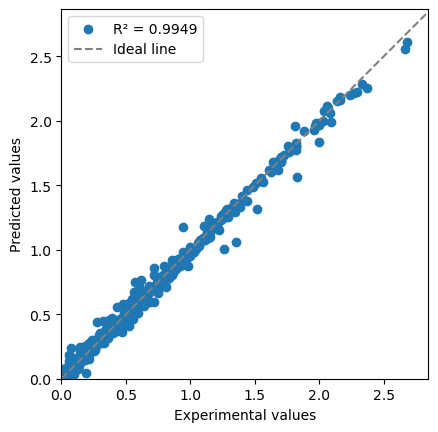

In [15]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

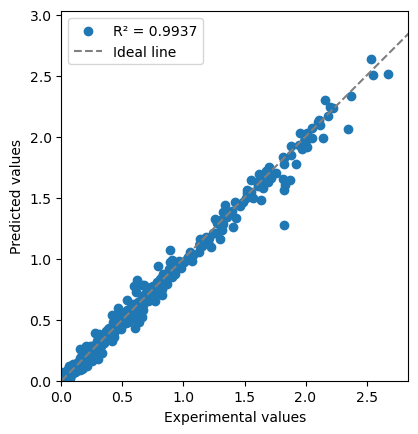

In [16]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values

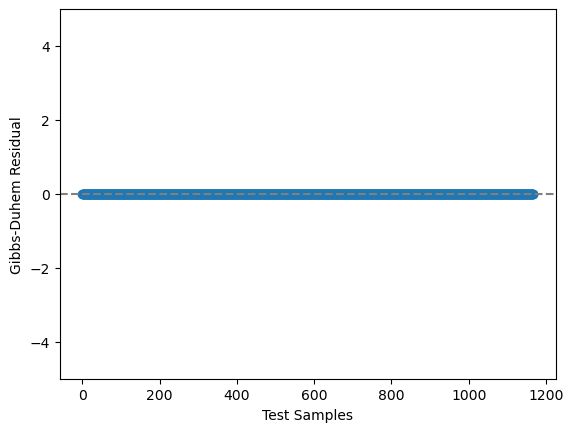

In [17]:
# Convert tensor to NumPy
np_gd_residuals = test_residuals.detach().cpu().numpy()

# Create index for each test sample
test_idxs = np.arange(len(np_gd_residuals))

# Plot residuals against observation index
plt.scatter(test_idxs, np_gd_residuals)
plt.axhline(0, color="gray", linestyle="--")
plt.ylim(-5, 5)
plt.xlabel("Test Samples")
plt.ylabel("Gibbs-Duhem Residual")
plt.show()

Evaluating the distribution of Gibbs-Duhem Residual Values

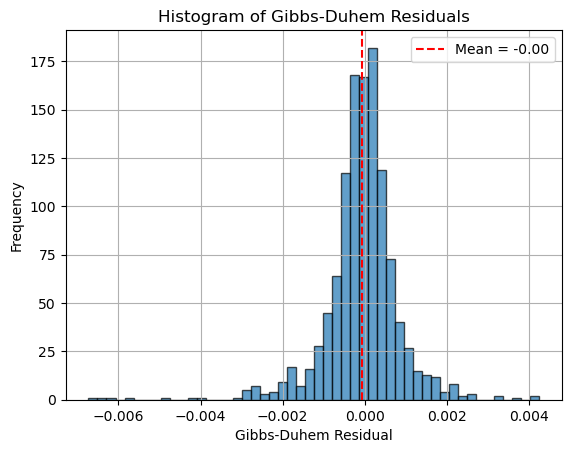

In [18]:
# Compute mean of residuals
mean_residual = np.mean(np_gd_residuals)

# Plot histogram
plt.hist(np_gd_residuals, bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    mean_residual, color="red", linestyle="--", label=f"Mean = {mean_residual:.2f}"
)
plt.xlabel("Gibbs-Duhem Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Gibbs-Duhem Residuals")
plt.legend()
plt.grid(True)
plt.show()

### PINN Comparison with Purely Data-Driven Neural Networks

In this section, we train the same architecture without the lambda_gd​ term, which embeds physics into the neural network's loss function. This allows us to compare the residuals between the physics-informed and purely data-driven approaches.

Define the hyperparameters

In [19]:
lr = study.best_params["learning_rate"]
lambda_gd = 0  # Set to zero to remove the physics
lambda_l1 = study.best_params["lambda_l1"]

Evaluating the neural network with the selected hyperparameters, using the same data which trained the PINN

In [20]:
# Model and optimizer
input_size = X_train.shape[1]
output_size = 2
nn_model = NeuralNetArchitecture(input_size, output_size).to(DEVICE)
nn_optimizer = torch.optim.Adam(nn_model.parameters(), lr=lr)

# Early stopping setup
nn_best_val_loss = float("inf")
nn_best_model_state = None
nn_patience = EPOCHS / 10
nn_patience_counter = 0

for epoch in range(EPOCHS):
    # Training
    nn_model.train()
    nn_outputs = nn_model(X_train_tensor)
    nn_loss = gibbs_duhem_loss(
        nn_outputs, y_train_tensor, X_train_tensor, nn_model, lambda_gd, lambda_l1
    )[0]

    nn_optimizer.zero_grad()
    nn_loss.backward()
    nn_optimizer.step()

    # Validation
    nn_model.eval()
    nn_val_outputs = nn_model(X_val_tensor)
    nn_val_loss = gibbs_duhem_loss(
        nn_val_outputs,
        y_val_tensor,
        X_val_tensor,
        nn_model,
        lambda_gd,
        lambda_l1,
    )[0]

    if nn_val_loss.item() < nn_best_val_loss:
        nn_best_val_loss = nn_val_loss.item()
        nn_best_model_state = nn_model.state_dict()
        nn_patience_counter = 0
    else:
        nn_patience_counter += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}: Training loss -> {nn_loss.item():.4f}, Validation loss -> {nn_val_loss.item():.4f}"
        )

    if nn_patience_counter >= nn_patience:
        print(
            f"Early stopping at epoch {epoch + 1}. Best validation loss: {nn_best_val_loss:.4f}"
        )
        break

# Load best model parameters
if nn_best_model_state is not None:
    nn_model.load_state_dict(nn_best_model_state)

# Final model evaluation
nn_model.eval()
nn_test_outputs = nn_model(X_test_tensor)
nn_test_loss, nn_test_mse, nn_test_gd, nn_test_residuals = gibbs_duhem_loss(
    nn_test_outputs, y_test_tensor, X_test_tensor, nn_model, lambda_gd, lambda_l1
)

print(f"\nFinal Test Loss: {nn_test_loss.item():.4f}")
print(f" - Test MSE Loss: {nn_test_mse.item():.4f}")
print(f" - Test GD Loss: {nn_test_gd.item():.4f}")

Epoch 20: Training loss -> 0.1950, Validation loss -> 0.1918
Epoch 40: Training loss -> 0.1488, Validation loss -> 0.1513
Epoch 60: Training loss -> 0.1263, Validation loss -> 0.1313
Epoch 80: Training loss -> 0.1069, Validation loss -> 0.1124
Epoch 100: Training loss -> 0.0946, Validation loss -> 0.0980
Epoch 120: Training loss -> 0.0852, Validation loss -> 0.0899
Epoch 140: Training loss -> 0.0762, Validation loss -> 0.0821
Epoch 160: Training loss -> 0.0685, Validation loss -> 0.0728
Epoch 180: Training loss -> 0.0629, Validation loss -> 0.0692
Epoch 200: Training loss -> 0.0607, Validation loss -> 0.0661
Epoch 220: Training loss -> 0.0490, Validation loss -> 0.0547
Epoch 240: Training loss -> 0.0441, Validation loss -> 0.0499
Epoch 260: Training loss -> 0.0420, Validation loss -> 0.0444
Epoch 280: Training loss -> 0.0366, Validation loss -> 0.0408
Epoch 300: Training loss -> 0.0355, Validation loss -> 0.0399
Epoch 320: Training loss -> 0.0325, Validation loss -> 0.0397
Epoch 340: T

Save the purely data-driven model. The scaler is not saved separately, as it is the same one used for the PINN model due to the identical data split.

In [21]:
# Save final model
torch.save(nn_model.state_dict(), MODEL_PATH / "trained_nn.pt")

Plotting Predicted vs Experimental Values for $\gamma_1$

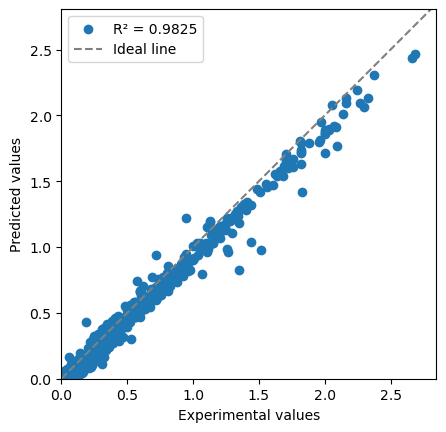

In [22]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(nn_test_outputs[:, 0], y_test_tensor[:, 0]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 0].cpu().numpy()
preds_np = nn_test_outputs[:, 0].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Predicted vs Experimental Values for $\gamma_2$

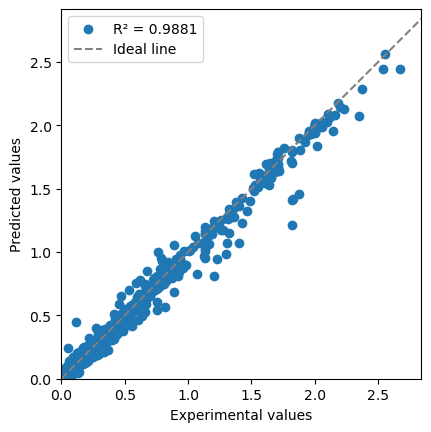

In [23]:
# Calculate R²
r2_metric = R2Score()
r2 = r2_metric(nn_test_outputs[:, 1], y_test_tensor[:, 1]).item()

# Convert tensors to CPU and NumPy for plotting
y_test_np = y_test_tensor[:, 1].cpu().numpy()
preds_np = nn_test_outputs[:, 1].detach().cpu().numpy()

# Plot the scatter plot
plt.scatter(y_test_np, preds_np, label=f"R² = {r2:.4f}")
plt.xlabel("Experimental values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])

# Plot ideal line - Predicted value equal to Experimental
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle="--",
    color="gray",
    label="Ideal line",
)

plt.legend(loc="upper left")
plt.show()

Plotting Gibbs-Duhem Residual Values Comparison

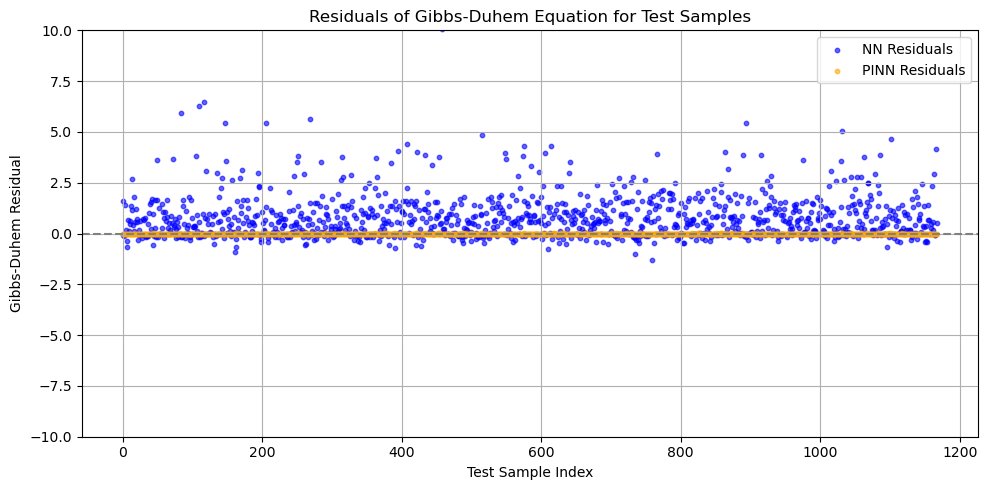

In [24]:
# Convert tensor to NumPy
nn_np_gd_residuals = nn_test_residuals.detach().cpu().numpy()

# Create index for each test sample
nn_test_idxs = np.arange(len(nn_np_gd_residuals))

# Plot residuals
plt.figure(figsize=(10, 5))
plt.scatter(
    nn_test_idxs,
    nn_np_gd_residuals,
    color="blue",
    alpha=0.6,
    label="NN Residuals",
    s=10,
)
plt.scatter(
    test_idxs, np_gd_residuals, color="orange", alpha=0.6, label="PINN Residuals", s=10
)

# Reference line at 0
plt.axhline(0, color="gray", linestyle="--")

# Labels and limits
plt.xlabel("Test Sample Index")
plt.ylabel("Gibbs-Duhem Residual")
plt.title("Residuals of Gibbs-Duhem Equation for Test Samples")
plt.ylim(-10, 10)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Evaluating the distribution of Gibbs-Duhem Residual Values comparison

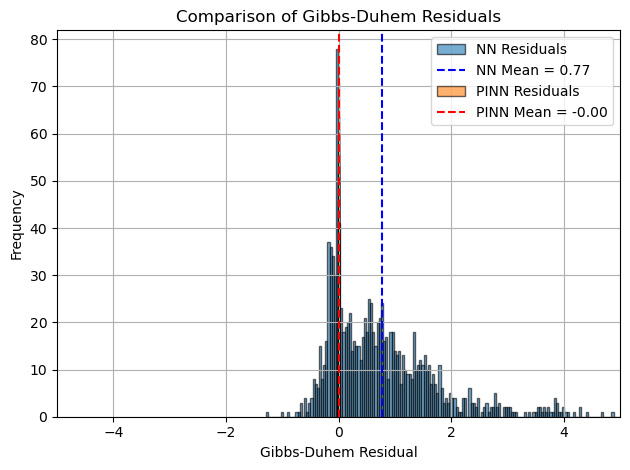

In [25]:
# Compute mean of residuals
nn_mean_residual = np.mean(nn_np_gd_residuals)

# Plot histograms
plt.hist(
    nn_np_gd_residuals, bins=300, edgecolor="black", alpha=0.6, label="NN Residuals"
)
plt.axvline(
    nn_mean_residual,
    color="blue",
    linestyle="--",
    label=f"NN Mean = {nn_mean_residual:.2f}",
)

plt.hist(np_gd_residuals, bins=150, edgecolor="black", alpha=0.6, label="PINN Residuals")
plt.axvline(
    mean_residual, color="red", linestyle="--", label=f"PINN Mean = {mean_residual:.2f}"
)

# Labels and styling
plt.xlabel("Gibbs-Duhem Residual")
plt.ylabel("Frequency")
plt.title("Comparison of Gibbs-Duhem Residuals")
plt.xlim(-5, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()